# Retail Sales Data — Exploratory Data Analysis

## Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on retail sales data to identify sales trends, customer behaviour, product performance, and actionable business insights.

## Technology Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df=pd.read_csv("retail_sales_dataset.csv")

In [4]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Age,Gender,Region,Product_Name,Product_Category,Quantity,Unit_Price,Discount,Sales_Amount,Payment_Method,Customer_Rating
0,ORD100001,2024-04-12,CUST1073,NaN,Female,North,Travel Mug,Accessories,4,854.05,0.00,3416.20,Net Banking,3.0
1,ORD100002,2025-03-11,CUST1017,19.0,Female,East,Laptop Backpack,Accessories,1,1363.95,0.10,1227.56,Credit Card,4.0
2,ORD100003,2024-09-27,CUST1009,28.0,Female,North,Running Shoes,Sports,1,3148.95,0.00,3148.95,UPI,5.0
3,ORD100004,2024-04-16,CUST1143,30.0,Female,East,Denim Jeans,Clothing,2,1799.00,0.05,3418.10,Debit Card,4.0
4,ORD100005,2024-03-12,CUST1152,27.0,Female,South,Office Chair,Furniture,1,7873.95,0.05,7480.25,UPI,4.0


In [5]:
df.shape

(1008, 14)

In [6]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Age', 'Gender',
       'Region', 'Product_Name', 'Product_Category', 'Quantity', 'Unit_Price',
       'Discount', 'Sales_Amount', 'Payment_Method', 'Customer_Rating'],
      dtype='str')

In [7]:
df.dtypes

Order_ID                str
Order_Date              str
Customer_ID             str
Customer_Age        float64
Gender                  str
Region                  str
Product_Name            str
Product_Category        str
Quantity              int64
Unit_Price          float64
Discount            float64
Sales_Amount        float64
Payment_Method          str
Customer_Rating     float64
dtype: object

In [8]:
df.info

<bound method DataFrame.info of        Order_ID  Order_Date Customer_ID  Customer_Age  Gender Region  \
0     ORD100001  2024-04-12    CUST1073           NaN  Female  North   
1     ORD100002  2025-03-11    CUST1017          19.0  Female   East   
2     ORD100003  2024-09-27    CUST1009          28.0  Female  North   
3     ORD100004  2024-04-16    CUST1143          30.0  Female   East   
4     ORD100005  2024-03-12    CUST1152          27.0  Female  South   
...         ...         ...         ...           ...     ...    ...   
1003  ORD100661  2025-07-09    CUST1198          28.0  Female  South   
1004  ORD100412  2025-11-22    CUST1113          40.0    Male  North   
1005  ORD100679  2025-06-09    CUST1040          36.0  Female   West   
1006  ORD100627  2024-05-11    CUST1160          37.0  Female  North   
1007  ORD100514  2025-08-29    CUST1168          52.0  Female  North   

         Product_Name Product_Category  Quantity  Unit_Price  Discount  \
0          Travel Mug      Ac

In [9]:
df.isnull().sum()

Order_ID             0
Order_Date           5
Customer_ID          0
Customer_Age        15
Gender              10
Region               8
Product_Name         0
Product_Category     5
Quantity             0
Unit_Price           0
Discount            12
Sales_Amount         0
Payment_Method       7
Customer_Rating     11
dtype: int64

In [10]:
missing = pd.DataFrame({
    "Missing_cont":df.isnull().sum(),
    "Missing-Percentage":(df.isnull().sum()/len(df)*100).round(2)})
print(missing)
                          

                  Missing_cont  Missing-Percentage
Order_ID                     0                0.00
Order_Date                   5                0.50
Customer_ID                  0                0.00
Customer_Age                15                1.49
Gender                      10                0.99
Region                       8                0.79
Product_Name                 0                0.00
Product_Category             5                0.50
Quantity                     0                0.00
Unit_Price                   0                0.00
Discount                    12                1.19
Sales_Amount                 0                0.00
Payment_Method               7                0.69
Customer_Rating             11                1.09


In [11]:
df.duplicated().sum()

np.int64(8)

In [12]:
df.describe()

,Customer_Age,Quantity,Unit_Price,Discount,Sales_Amount,Customer_Rating
count,993.000000,1008.000000,1008.000000,996.000000,1008.000000,997.000000
mean,41.660624,3.044643,2043.871032,0.070231,5929.594524,3.819458
std,13.822121,1.400451,1868.408298,0.061308,6673.998933,1.117361
min,18.000000,1.000000,379.050000,0.000000,303.240000,1.000000
25%,30.000000,2.000000,799.000000,0.000000,1784.110000,3.000000
50%,42.000000,3.000000,1519.050000,0.050000,3595.750000,4.000000
75%,53.000000,4.000000,2499.000000,0.100000,7195.500000,5.000000
max,65.000000,5.000000,7873.950000,0.200000,37495.000000,5.000000


In [13]:
numeric_cols= df.select_dtypes(include=np.number).columns
statistics=pd.DataFrame({
    "mean":df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode":df[numeric_cols].mode().iloc[0],
    "standard Deviation":df[numeric_cols].std()
                        })
print(statistics)


                        mean   Median     Mode  standard Deviation
Customer_Age       41.660624    42.00    34.00           13.822121
Quantity            3.044643     3.00     4.00            1.400451
Unit_Price       2043.871032  1519.05   418.95         1868.408298
Discount            0.070231     0.05     0.00            0.061308
Sales_Amount     5929.594524  3595.75  7196.00         6673.998933
Customer_Rating     3.819458     4.00     4.00            1.117361


In [14]:
df["Order_Date"]=pd.to_datetime(df["Order_Date"])

In [15]:
df["Order_Date"].dtype

dtype('<M8[us]')

In [16]:
df["year"]=df["Order_Date"].dt.year
df["Month"]=df["Order_Date"].dt.month


In [17]:
df[["Order_Date","year","Month"]].head()

,Order_Date,year,Month
0,2024-04-12,2024.0,4.0
1,2025-03-11,2025.0,3.0
2,2024-09-27,2024.0,9.0
3,2024-04-16,2024.0,4.0
4,2024-03-12,2024.0,3.0


In [18]:
monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Sales_Amount"].sum()

In [19]:
monthly_sales

Order_Date
2024-01    281245.49
2024-02    297881.34
2024-03    221508.42
2024-04    360185.44
2024-05    252394.81
2024-06    198157.20
2024-07    203484.62
2024-08    355574.38
2024-09    280330.43
2024-10    130345.26
2024-11    160787.44
2024-12    233667.98
2025-01    300879.63
2025-02    187990.15
2025-03    176448.10
2025-04    230104.07
2025-05    341734.64
2025-06    199367.05
2025-07    280268.81
2025-08    143494.49
2025-09    172770.22
2025-10    346570.64
2025-11    297747.15
2025-12    285876.57
Freq: M, Name: Sales_Amount, dtype: float64

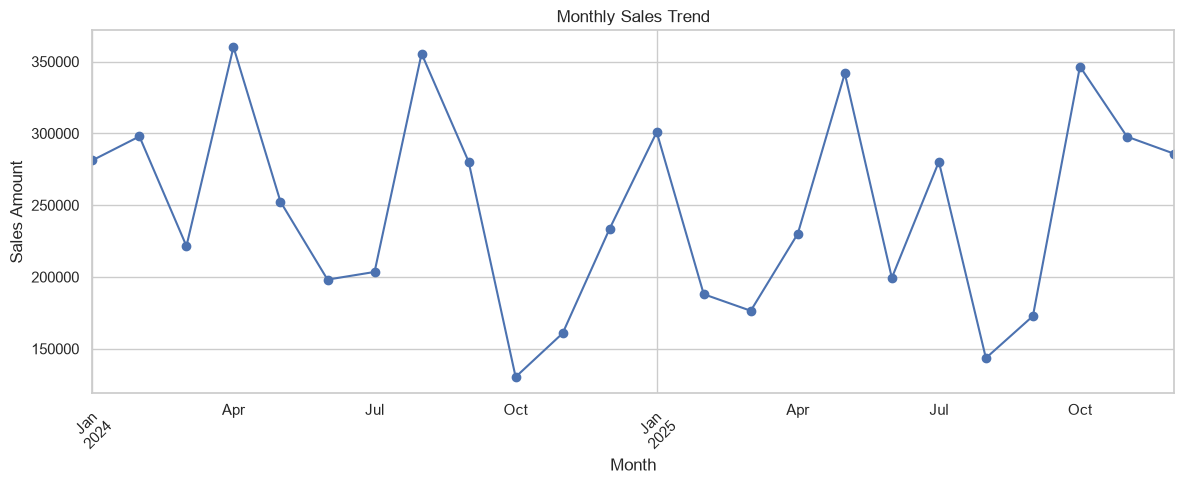

In [20]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The monthly sales trend shows how sales performance changes over time. Peaks indicate months with relatively higher sales, while declines indicate weaker sales periods. These variations can help identify seasonal patterns and periods that may require additional promotional activities.

In [21]:
quarterly_sales = df.groupby(
    df["Order_Date"].dt.to_period("Q")
)["Sales_Amount"].sum()

In [22]:
quarterly_sales

Order_Date
2024Q1    800635.25
2024Q2    810737.45
2024Q3    839389.43
2024Q4    524800.68
2025Q1    665317.88
2025Q2    771205.76
2025Q3    596533.52
2025Q4    930194.36
Freq: Q-DEC, Name: Sales_Amount, dtype: float64

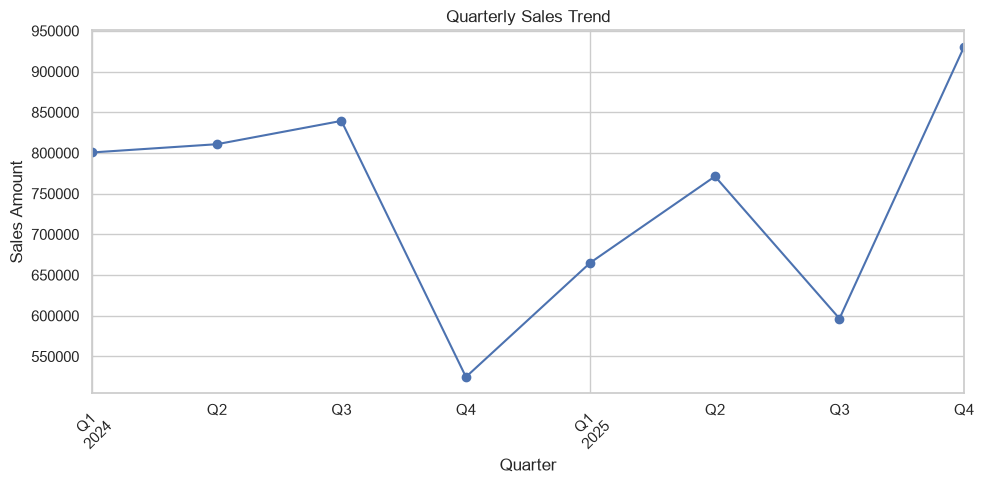

In [23]:
plt.figure(figsize=(10, 5))

quarterly_sales.plot(kind="line", marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The quarterly sales analysis provides a broader view of business performance by grouping monthly 
sales into three-month periods.

The strongest quarter was 2025 Q4, with total sales of approximately 930,194.36, while the weakest 
quarter was 2024 Q4, with approximately 524,800.68 in sales.

The significant difference between the strongest and weakest quarters indicates that quarterly sales 
performance can vary considerably. The business should identify the factors contributing to stronger 
quarters and use those strategies to improve weaker periods.

In [24]:
bins = [17, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]

df["Age_Group"] = pd.cut(
    df["Customer_Age"],
    bins=bins,
    labels=labels
)

In [25]:
df["Age_Group"].value_counts().sort_index()

Age_Group
18-25    163
26-35    203
36-45    208
46-55    220
56-65    199
Name: count, dtype: int64

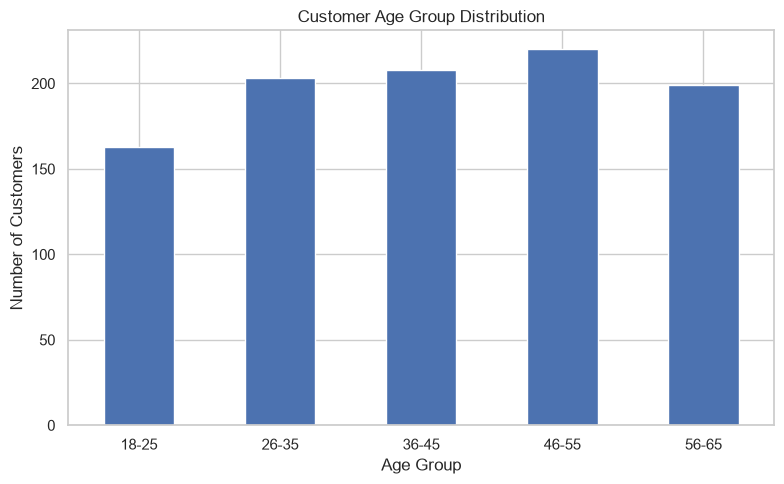

In [26]:
plt.figure(figsize=(8, 5))

df["Age_Group"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
gender_counts = df["Gender"].value_counts()
gender_counts

Gender
Male      495
Female    471
Other      32
Name: count, dtype: int64

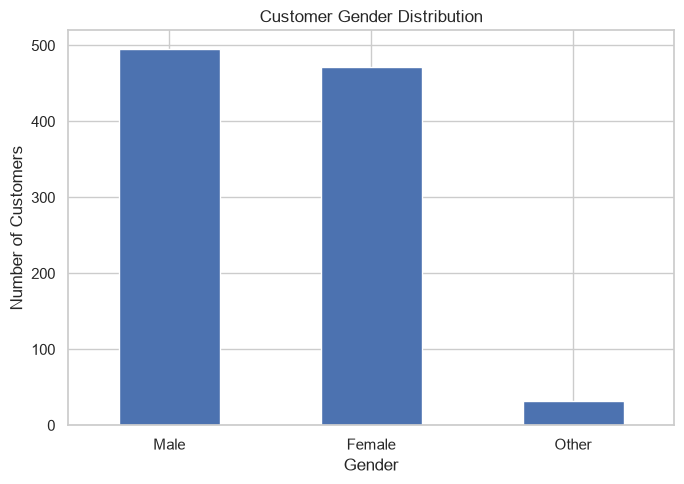

In [28]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind="bar")

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
top_products = df.groupby("Product_Name")["Quantity"].sum().sort_values(
    ascending=False
).head(10)

top_products

Product_Name
Office Chair      262
Running Shoes     255
Notebook Set      229
Power Bank        224
Water Bottle      220
Denim Jeans       209
Cotton T-Shirt    209
USB-C Hub         194
Travel Mug        194
Smart Watch       187
Name: Quantity, dtype: int64

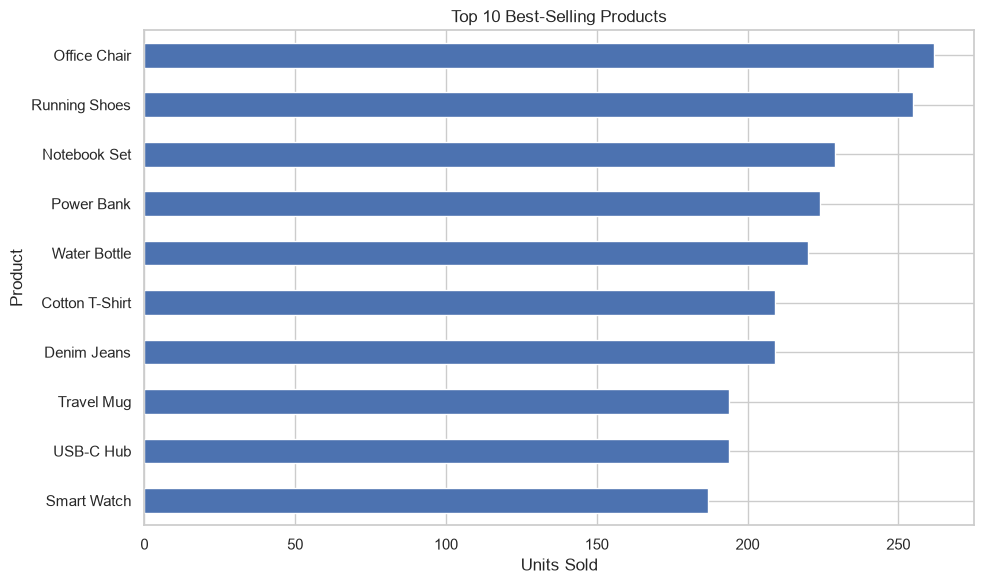

In [30]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [31]:
category_revenue = df.groupby(
    "Product_Category"
)["Sales_Amount"].sum().sort_values(ascending=False)

category_revenue

Product_Category
Electronics    2175555.36
Furniture      2012424.64
Sports          825860.44
Clothing        487633.71
Accessories     362200.00
Stationery       83154.62
Name: Sales_Amount, dtype: float64

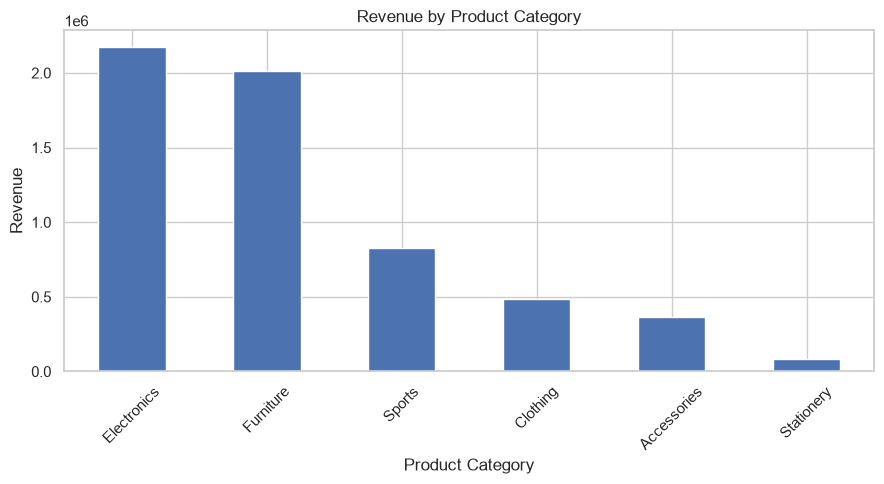

In [32]:
plt.figure(figsize=(9, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
correlation = df.select_dtypes(include=np.number).corr()

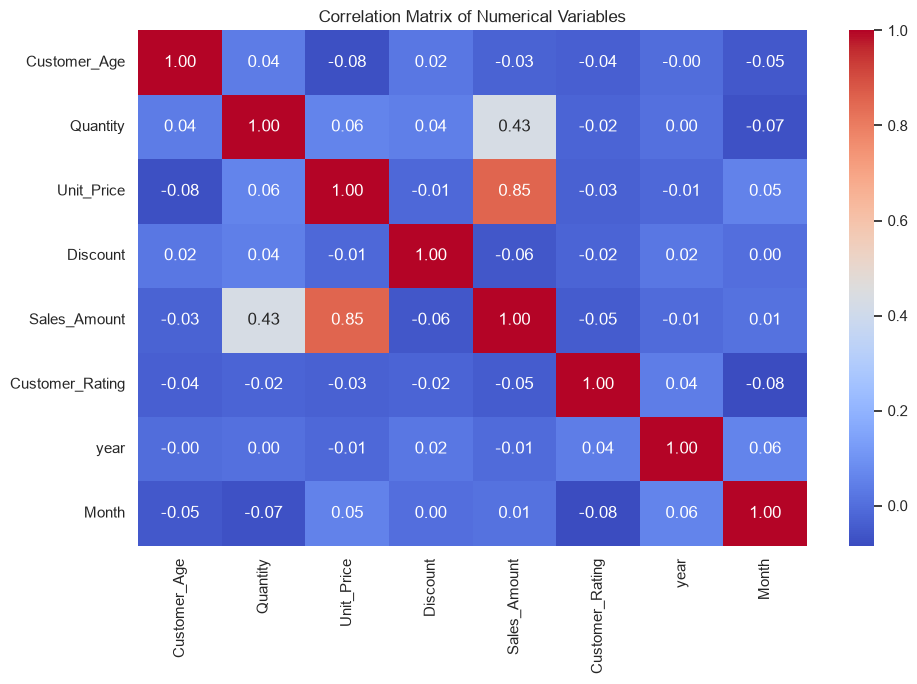

In [35]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

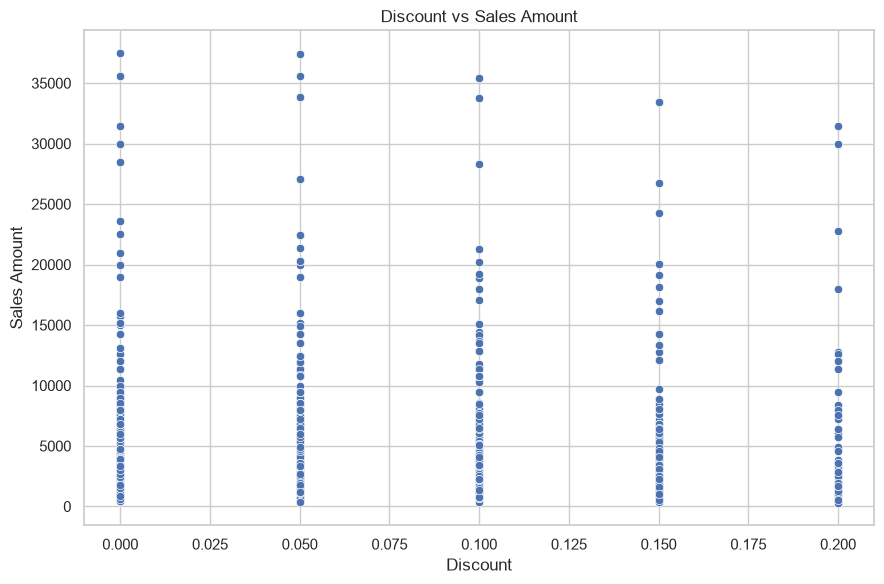

In [39]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Sales_Amount"
)

plt.title("Discount vs Sales Amount")
plt.xlabel("Discount")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()

# Conclusion and Business Recommendations

## Key Insights

1. Monthly and quarterly sales trends reveal changes in sales performance over time.
2. Customer age and gender analysis helps identify the major customer groups.
3. The top-selling products indicate which products have the strongest demand.
4. Revenue by category identifies the most valuable product categories.
5. Correlation analysis helps identify relationships between numerical variables.
6. Discount and sales analysis provides additional insight into pricing and promotional behaviour.

## Business Recommendations

1. Increase promotional campaigns during months or quarters with weaker sales performance.
2. Maintain sufficient inventory for the top-selling products to avoid stock shortages.
3. Focus marketing campaigns on the customer demographic groups with the highest purchase participation.
4. Prioritize high-revenue product categories when planning inventory and promotions.
5. Use discount strategies carefully and evaluate whether discounts are actually increasing sales.

In [42]:
gender_summary = df["Gender"].value_counts()

gender_summary

Gender
Male      495
Female    471
Other      32
Name: count, dtype: int64

In [43]:
gender_percentage = (
    df["Gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

gender_percentage

Gender
Male      49.60
Female    47.19
Other      3.21
Name: proportion, dtype: float64

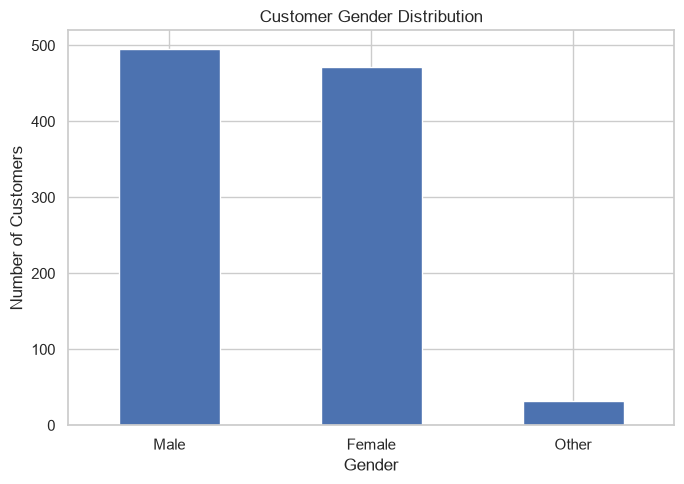

In [44]:
plt.figure(figsize=(7, 5))

gender_summary.plot(
    kind="bar",
    title="Customer Gender Distribution"
)

plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The gender distribution shows the participation of different customer groups in the retail dataset. The group with the higher number of customers represents a larger share of the observed customer base.

In [45]:
top_products = (
    df.groupby("Product_Name")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product_Name
Office Chair      262
Running Shoes     255
Notebook Set      229
Power Bank        224
Water Bottle      220
Denim Jeans       209
Cotton T-Shirt    209
USB-C Hub         194
Travel Mug        194
Smart Watch       187
Name: Quantity, dtype: int64

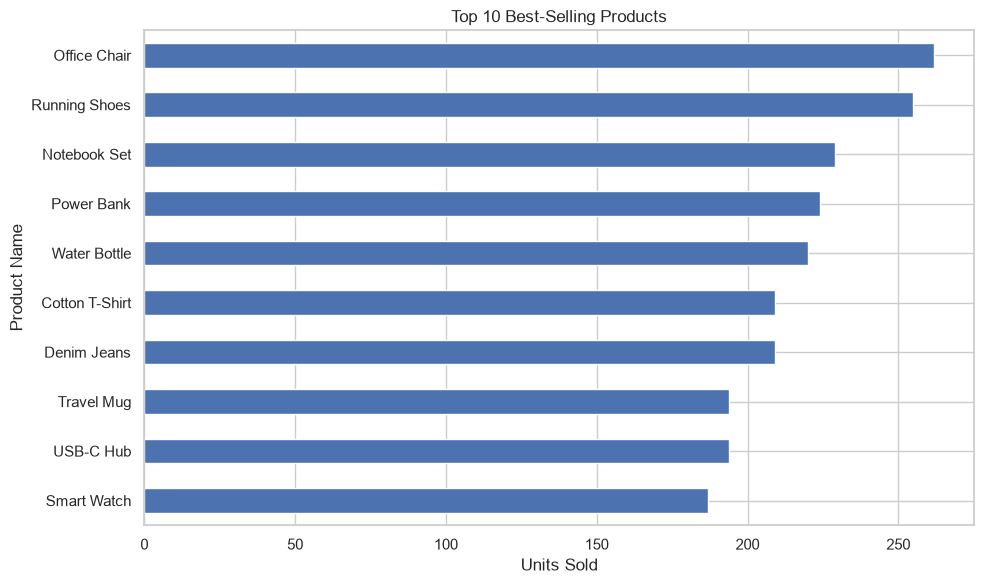

In [46]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Units Sold")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

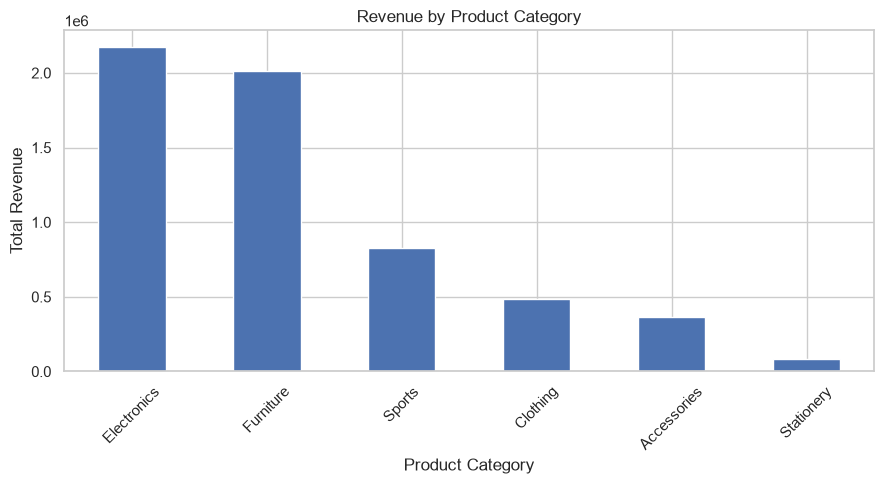

In [47]:
plt.figure(figsize=(9, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The revenue by product category chart shows the contribution of each product category to total sales. The category with the highest revenue represents the strongest contributor to overall business revenue.

## Correlation Analysis

Correlation analysis is used to understand the relationships between numerical variables in the dataset.
A correlation value close to +1 indicates a strong positive relationship, while a value close to -1 
indicates a strong negative relationship. A value near 0 indicates a weak relationship.

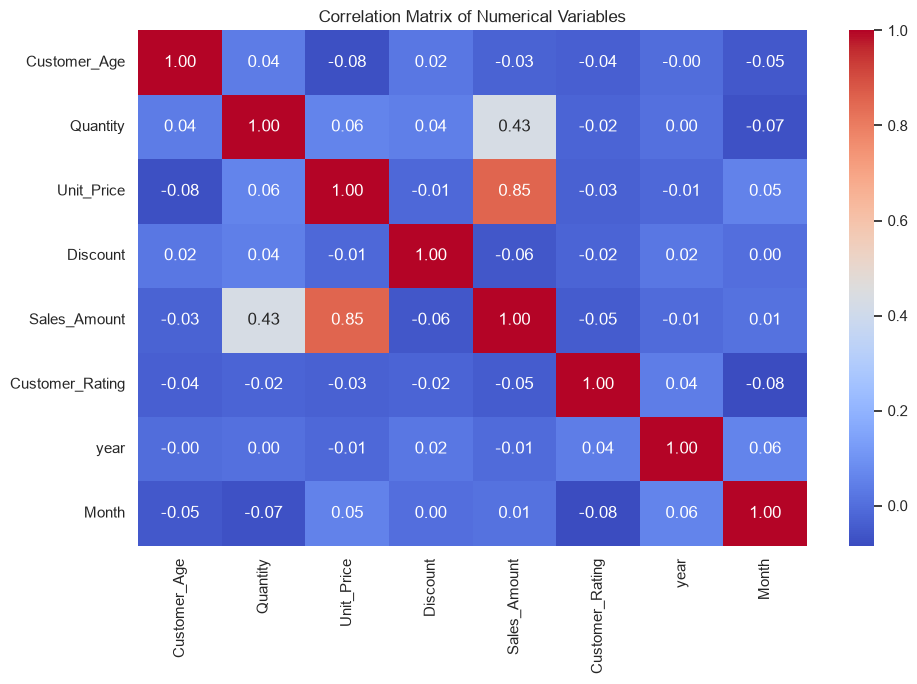

In [54]:
numeric_data = df.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the strength of relationships between the numerical variables.

The strongest positive or negative correlations can help identify variables that may be related to 
sales performance. Variables with weak correlations indicate that there is little linear relationship 
between them.

This analysis can help identify which numerical variables may be useful for further business analysis.

## Additional Analysis: Sales by Region

Regional analysis helps identify geographical differences in sales performance. 
Comparing total sales across regions can reveal which areas contribute most to the business.

In [56]:
region_sales = (
    df.groupby('Region')['Sales_Amount']
      .sum()
      .sort_values(ascending=False)
)

region_sales

Region
South    1747161.34
North    1607664.83
West     1605412.28
East      978258.25
Name: Sales_Amount, dtype: float64

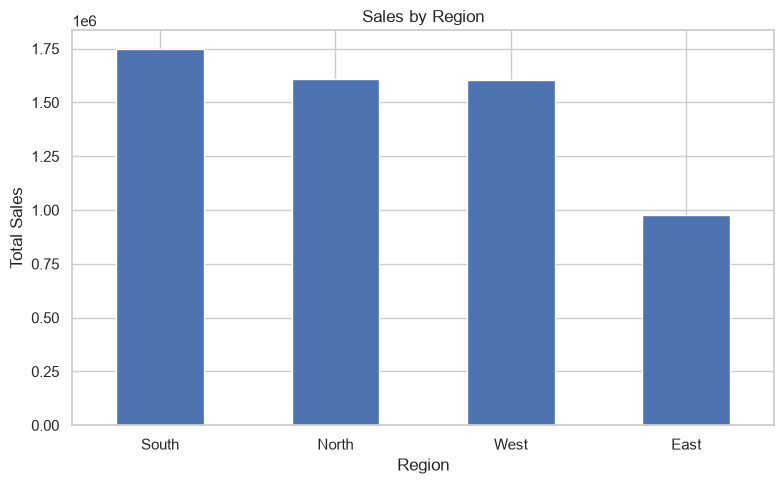

In [57]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The regional sales chart shows differences in total sales across the regions.

The region with the highest total sales represents the strongest geographical market, while the region 
with the lowest sales may require further investigation.

The business can use this insight to allocate marketing budgets, inventory, and promotional campaigns 
according to regional sales performance.